## 1. What this notebook computes

The canonical anticommutator of dirac16complex contains the matrix $B =
-iC\gamma^{(x_4)}$, which has eight positive and eight negative eigenvalues: the
charge $\Psi^\dagger B\Psi$ is indefinite. Could a cleverer choice of the charge
density avoid this? This notebook answers no, and then asks which symmetry
transformations of the spinor keep the canonical anticommutator. It

- finds EVERY matrix $G$ for which the bilinear form $\Psi^TG\Phi$ is unchanged by
  the 28 generators $S^{ab} = \frac14[\gamma^{(x_a)}, \gamma^{(x_b)}]$ of Spin(4,4):
  the solutions form a two-dimensional family, spanned by $CP_-$ and $CP_+$, where
  $P_\mp = \frac12(I \mp \Gamma)$ are the projectors onto the two chiral halves;
- shows that every charge density made from such a form and the time direction,
  the Hermitian part of $cG\gamma^{(x_4)}$, satisfies $\Gamma X\Gamma = -X$ and
  therefore has as many negative as positive eigenvalues (unless it is zero);
- sorts the 28 generators: which are anti-Hermitian (their exponentials are
  unitary), which commute with $B$, and which are *Krein-unitary* (their
  exponentials keep $B$): exactly the 21 generators that do not involve $x_4$, the
  generators of Spin(4,3);
- follows finite rotations and boosts and draws what happens to the ordinary
  squared length and to the Krein norm of a column;
- reproduces the recorded checks and draws five teaching figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10e (Invariant forms and Krein-unitary symmetries) is the file
`Revision/textbook/notebooks/10e_invariant_forms.ipynb` of the repository Dirac_claude.
It finds every bilinear form of the 16 components that is invariant under the 28
generators of Spin(4,4) (a two-dimensional family, spanned by C times the two chiral
projectors), shows that every charge density built from such a form and the time
direction x4 has as many negative as positive eigenvalues, so that no choice makes the
charge positive; it then sorts the 28 generators by whether they keep the canonical
anticommutator (Krein-unitary: the 21 that do not involve x4) and whether they are
unitary (9 do both), follows finite rotations and boosts, reproduces the recorded checks,
and draws five teaching figures. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy and matplotlib; the other packages run Jupyter, the program that shows and
runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10e_invariant_forms.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10e_invariant_forms.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10e_invariant_forms.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/10e.captions.json`
- `Revision/textbook/figures/10e_1_invariant_forms.png`
- `Revision/textbook/figures/10e_2_singular_values.png`
- `Revision/textbook/figures/10e_3_density_eigenvalues.png`
- `Revision/textbook/figures/10e_4_generator_types.png`
- `Revision/textbook/figures/10e_5_finite_transformations.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10e_5_finite_transformations.png exists
    ALL 15 CHECKS PASSED (notebook 10e)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10e_invariant_forms.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below the folder Revision: the notebook reads files of
  the Revision record: the data it starts from and the report files whose checks it
  reproduces (each cited check must still exist there with the verdict PASS). It must be
  opened inside the folder Revision/textbook/notebooks of a complete copy of the
  repository (a notebook copied alone to another folder cannot find them). Clone the
  repository again and open the notebook there.
- "AssertionError: the cited record check is missing or not PASS": a report file of the
  Revision record no longer holds the check that the notebook names, or holds it with
  another verdict: the copy of the repository is incomplete or was changed. Clone the
  repository again and open the notebook there.
- "Jupyter command `jupyter-lab` not found" or "Jupyter command `jupyter-nbconvert` not
  found" after a command that starts with `python -m jupyter`: that form still has to
  find the programs jupyter-lab and jupyter-nbconvert in the folders where the terminal
  looks for programs, and it did not find them there. Do Step 4 and type `jupyter` again.
  Or start the two programs through Python itself, in the folder of the notebook: the
  first command below does what `jupyter lab` does in Step 5, the second what `jupyter
  nbconvert` does in Step 6.

      python -m jupyterlab 10e_invariant_forms.ipynb
      python -m nbconvert --to notebook --execute --inplace 10e_invariant_forms.ipynb

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10e (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10e (Invariant forms and Krein-unitary symmetries) is the file
# Revision/textbook/notebooks/10e_invariant_forms.ipynb of the repository Dirac_claude.
# It finds every bilinear form of the 16 components that is invariant under the 28
# generators of Spin(4,4) (a two-dimensional family, spanned by C times the two chiral
# projectors), shows that every charge density built from such a form and the time
# direction x4 has as many negative as positive eigenvalues, so that no choice makes the
# charge positive; it then sorts the 28 generators by whether they keep the canonical
# anticommutator (Krein-unitary: the 21 that do not involve x4) and whether they are
# unitary (9 do both), follows finite rotations and boosts, reproduces the recorded
# checks, and draws five teaching figures. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy and matplotlib; the other packages run Jupyter, the
# program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10e_invariant_forms.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10e_invariant_forms.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10e_invariant_forms.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/10e.captions.json
# - Revision/textbook/figures/10e_1_invariant_forms.png
# - Revision/textbook/figures/10e_2_singular_values.png
# - Revision/textbook/figures/10e_3_density_eigenvalues.png
# - Revision/textbook/figures/10e_4_generator_types.png
# - Revision/textbook/figures/10e_5_finite_transformations.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10e_5_finite_transformations.png exists
#     ALL 15 CHECKS PASSED (notebook 10e)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10e_invariant_forms.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below the folder Revision: the notebook reads files of
#   the Revision record: the data it starts from and the report files whose checks it
#   reproduces (each cited check must still exist there with the verdict PASS). It must
#   be opened inside the folder Revision/textbook/notebooks of a complete copy of the
#   repository (a notebook copied alone to another folder cannot find them). Clone the
#   repository again and open the notebook there.
# - "AssertionError: the cited record check is missing or not PASS": a report file of the
#   Revision record no longer holds the check that the notebook names, or holds it with
#   another verdict: the copy of the repository is incomplete or was changed. Clone the
#   repository again and open the notebook there.
# - "Jupyter command jupyter-lab not found" or "Jupyter command jupyter-nbconvert not
#   found" after a command that starts with python -m jupyter: that form still has to
#   find the programs jupyter-lab and jupyter-nbconvert in the folders where the terminal
#   looks for programs, and it did not find them there. Do Step 4 and type jupyter again.
#   Or start the two programs through Python itself, in the folder of the notebook: the
#   first command below does what jupyter lab does in Step 5, the second what jupyter
#   nbconvert does in Step 6.
#     python -m jupyterlab 10e_invariant_forms.ipynb
#     python -m nbconvert --to notebook --execute --inplace 10e_invariant_forms.ipynb
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10e"  # this notebook: chapter 10, example e


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10e complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Generator, Spin(4,4)**: the 28 matrices $S^{ab}$ ($a < b$) generate the spin
  transformations $R = \exp(\theta S^{ab})$, which turn the frame of the eight
  directions; their products form Spin(4,4). Spin(4,3) is the part generated by the
  21 $S^{ab}$ with $a, b \neq x_4$ (the transformations that leave the time $x_4$
  alone).
- **Bilinear form, invariant**: a form $\Psi^TG\Phi$ with a $16 \times 16$ matrix $G$.
  It is *invariant* if it does not change when both columns are transformed by the
  same spin transformation; to first order in $\theta$ this is the condition
  $(S^{ab})^TG + GS^{ab} = 0$ for all 28 generators.
- **Hermitian form, charge density**: a form $\Psi^\dagger X\Psi$ with a Hermitian
  matrix $X$; it is real for every $\Psi$. A charge density is the time component
  of a current.
- **Chiral projectors**: $P_\mp = \frac12(I \mp \Gamma)$ with the chirality $\Gamma =
  \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)} = \mathrm{diag}(-I_8, I_8)$;
  $P_-$ keeps components 1 to 8, $P_+$ components 9 to 16.
- **Singular values**: for a matrix $M$ the square roots of the eigenvalues of
  $M^TM$. The number of zero singular values of $M$ is the number of independent
  solutions of $Mx = 0$.
- **Unitary, Krein-unitary**: $R$ is unitary if $R^\dagger R = I$ (it keeps the
  ordinary length), Krein-unitary if $R^\dagger BR = B$ (it keeps the Krein form and
  the canonical anticommutator). For $R = \exp(\theta S)$ the first-order
  conditions are $S^\dagger = -S$ and $S^\dagger B + BS = 0$.
- **Rotation, boost**: $R = \exp(\theta S^{ab})$ is a rotation when $a$ and $b$ are
  both space-like or both time-like ($S^2 = -\frac14 I$, cosines and sines), and a
  boost when one is space-like and one time-like ($S^2 = +\frac14 I$, hyperbolic
  cosines and sines).

## 4. The physical and mathematical situation

**Why invariant forms are the right candidates.** Under a spin transformation
$\Psi \to R\Psi$ the form $\Psi^TG\Psi$ becomes $\Psi^TR^TGR\Psi$. For $R = I +
\theta S$ with small $\theta$, $R^TGR = G + \theta(S^TG + GS) + \theta^2S^TGS$; the
form is unchanged to first order exactly when $S^TG + GS = 0$. The gammas, and
hence the $S^{ab}$, are real, so $S^\dagger = S^T$, and the same condition makes the
Hermitian form $\Psi^\dagger G\Psi$ invariant. The notebook solves these
$28 \times 256$ linear equations for the 256 entries of $G$.

**Why every such density is indefinite.** The solutions will be $G = r_-CP_- +
r_+CP_+$. Both $C$ and $P_\mp$ commute with $\Gamma$ ($C$ is a product of four
gammas, an even number), so $G$ commutes with $\Gamma$; $\gamma^{(x_4)}$
anticommutes with $\Gamma$. Hence $\Gamma(cG\gamma^{(x_4)})\Gamma =
cG\Gamma\gamma^{(x_4)}\Gamma = -cG\gamma^{(x_4)}$, and the same for its Hermitian
part $X$: $\Gamma X\Gamma = -X$. If $Xv = \lambda v$, then $X(\Gamma v) = -\Gamma Xv
= -\lambda\,\Gamma v$: every eigenvalue $\lambda$ comes with $-\lambda$, with the
same multiplicity. So the density $\Psi^\dagger X\Psi$ is indefinite unless $X = 0$.
The canonical choice is $B = -iC\gamma^{(x_4)}$ ($r_- = r_+ = 1$, $c = -i$).

**Which transformations keep $B$.** $B$ is $-i$ times the product of the five gammas
$\gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}\gamma^{(x_4)}$. A gamma of
$x_1, x_2, x_3, x_4, x_8$ anticommutes with four of the five factors and commutes
with itself, so it commutes with $B$; a gamma of $x_5, x_6, x_7$ anticommutes with
all five and so anticommutes with $B$. For an anti-Hermitian generator the Krein
condition $S^\dagger B + BS = 0$ means $[B, S] = 0$; for a Hermitian one it means
$\{B, S\} = 0$. The notebook counts the generators of each kind.

## 5. The gammas, the generators and the chiral projectors

The next cell reads the gammas, builds $C$, $\Gamma$, $B$, the projectors $P_\mp$,
the 28 generators $S^{ab}$ ($a < b$) and the helper `check_record` (the PASS line
and the line of the reproduced Revision record are printed in one piece, so that
the stored output is the same in every run). It checks the recorded relations of
$B$ with the gammas.
Before it checks anything, `check_record` asks the helper `record_says_pass` whether
the cited record still says PASS: for a record name of the form
`<report file>, check <check name>` it opens that report (each file once, kept in
the dictionary `REPORT_CHECKS`) and stops the notebook with an error unless a check
of that name exists there with the verdict PASS; a record name without `, check `
names a data entry that the notebook reads and compares itself.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import itertools  # all pairs (a, b) with a < b
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices
from matplotlib.colors import LinearSegmentedColormap, ListedColormap  # colours


REPORT_CHECKS = {}  # report file -> {check name: verdict}; each file is read once


def record_says_pass(record):
    """True if the cited report check exists today with the verdict PASS."""
    path, separator, check_name = record.partition(", check ")
    if not separator:  # a data entry of a record file that the notebook reads itself
        return True
    if path not in REPORT_CHECKS:
        checks = json.loads(repository_file(path).read_text(encoding="utf-8"))["checks"]
        REPORT_CHECKS[path] = {c["name"]: c["verdict"].upper() for c in checks}
    return REPORT_CHECKS[path].get(check_name) == "PASS"


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    if not record_says_pass(record):  # the cited check must exist and say PASS
        raise AssertionError("the cited record check is missing or not PASS: " + record)
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#184f95", "#f0efec", "#e34948"])
fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=float) for a in range(1, 9)}
eta = {a: fixture["eta"][a - 1] for a in range(1, 9)}
I16 = np.eye(16)
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]
Gamma = (gamma[8] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5]
         @ gamma[6] @ gamma[7])
B = -1j * (C @ gamma[4])
P_minus, P_plus = (I16 - Gamma) / 2, (I16 + Gamma) / 2  # the chiral projectors
pairs = list(itertools.combinations(range(1, 9), 2))  # (1, 2), (1, 3), ..., (7, 8)
S = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4 for a, b in pairs}
report("number of generators S^ab", len(S))
commuting = [a for a in range(1, 9) if np.array_equal(B @ gamma[a], gamma[a] @ B)]
anticommuting = [a for a in range(1, 9) if np.array_equal(B @ gamma[a], -gamma[a] @ B)]
say(f"B commutes with gamma^(x_a) for a = {commuting}, anticommutes for a = "
    f"{anticommuting}")
check_record(commuting == [1, 2, 3, 4, 8] and anticommuting == [5, 6, 7],
             "B commutes with the gammas of x1, x2, x3, x4, x8, anticommutes with x5-x7",
             record="Revision/algebra/reports/python-algebra.json, check "
                    "B_gamma_relations")

RESULT number of generators S^ab = 28
B commutes with gamma^(x_a) for a = [1, 2, 3, 4, 8], anticommutes for a = [5, 6, 7]
PASS B commutes with the gammas of x1, x2, x3, x4, x8, anticommutes with x5-x7
     reproduces Revision/algebra/reports/python-algebra.json, check B_gamma_relations


## 6. Every invariant bilinear form

The unknown $G$ has 256 entries; write them as one long column $\vec G$ (row after
row). The matrix equation $S^TG + GS = 0$ is linear in $\vec G$: with the rule
"the row-by-row column of $AXD$ is $(A \otimes D^T)\vec X$" ($\otimes$ is the
Kronecker product, `np.kron`), it reads $(S^T \otimes I + I \otimes S^T)\vec G = 0$.
Stacking the 28 generators gives a matrix $M$ with $28 \cdot 256 = 7168$ rows and
256 columns, and the invariant forms are the solutions of $M\vec G = 0$.

The number of independent solutions is the number of zero singular values of $M$,
that is the number of zero eigenvalues of the $256 \times 256$ matrix $M^TM$. The
next cell computes them. Because $M$ is made of the numbers $0, \pm\frac14,
\pm\frac12$, a nonzero eigenvalue of $M^TM$ cannot be tiny; the cell prints the
smallest nonzero one and the largest "zero" one, to show that the separation is
enormous, so rounding cannot change the count. Then it checks EXACTLY (the entries
of $C$, $P_\mp$ and $S^{ab}$ are multiples of $\frac12$ and $\frac14$, which the
computer stores without rounding) that $CP_-$ and $CP_+$ solve every equation and
are independent, so they span the whole solution space.

In [3]:
rows = [np.kron(s.T, I16) + np.kron(I16, s.T) for s in S.values()]
M = np.vstack(rows)  # 7168 rows, 256 columns
values = np.linalg.eigvalsh(M.T @ M)  # 256 eigenvalues, sorted, all >= 0
zero_count = int(np.sum(values < 1e-9))
report("shape of M", M.shape)
report("eigenvalues of M^T M below 1e-9 (independent invariant forms)", zero_count)
report("largest of them and smallest nonzero eigenvalue",
       f"{values[zero_count - 1]:.1e} and {values[zero_count]:.4f}")

forms = {"C P_minus": C @ P_minus, "C P_plus": C @ P_plus}
exact_ok = all(np.array_equal(s.T @ G + G @ s, np.zeros((16, 16)))
               for G in forms.values() for s in S.values())
independent = np.linalg.matrix_rank(np.vstack([G.reshape(1, -1)
                                               for G in forms.values()])) == 2
check(zero_count == 2 and exact_ok and independent,
      "the invariant bilinear forms are exactly the combinations of C P- and C P+")
check_record(all(np.array_equal(s.T @ C + C @ s, np.zeros((16, 16)))
                 for s in S.values()),
             "C itself (= C P- + C P+) is invariant: Psibar Psi is a Spin(4,4) scalar",
             record="Revision/algebra/reports/wolfram-algebra.json, check "
                    "S_preserves_C")
check_record(all(np.array_equal(Gamma @ s, s @ Gamma) for s in S.values()),
             "every generator commutes with Gamma: the chiral halves are invariant",
             record="Revision/algebra/reports/python-algebra.json, check "
                    "S_preserves_C_and_commutes_with_Gamma")

RESULT shape of M = (7168, 256)
RESULT eigenvalues of M^T M below 1e-9 (independent invariant forms) = 2
RESULT largest of them and smallest nonzero eigenvalue = 1.3e-15 and 7.0000
PASS the invariant bilinear forms are exactly the combinations of C P- and C P+
PASS C itself (= C P- + C P+) is invariant: Psibar Psi is a Spin(4,4) scalar
     reproduces Revision/algebra/reports/wolfram-algebra.json, check S_preserves_C
PASS every generator commutes with Gamma: the chiral halves are invariant
     reproduces Revision/algebra/reports/python-algebra.json, check
    S_preserves_C_and_commutes_with_Gamma


The next cell draws the two invariant forms as heat maps and the 256 eigenvalues of
$M^TM$ on a logarithmic scale, where the two zeros stand far below all the others.

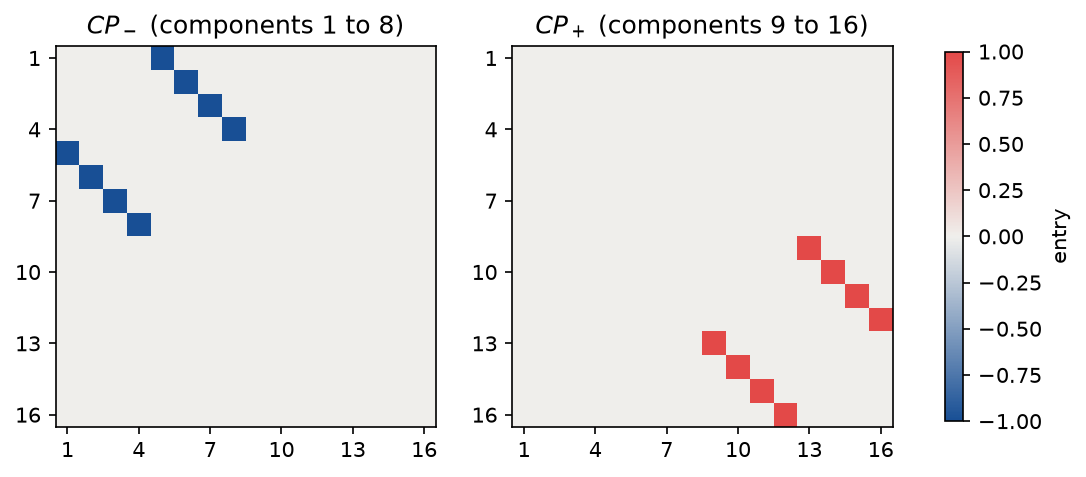

Figure 10e.1 saved as Revision/textbook/figures/10e_1_invariant_forms.png


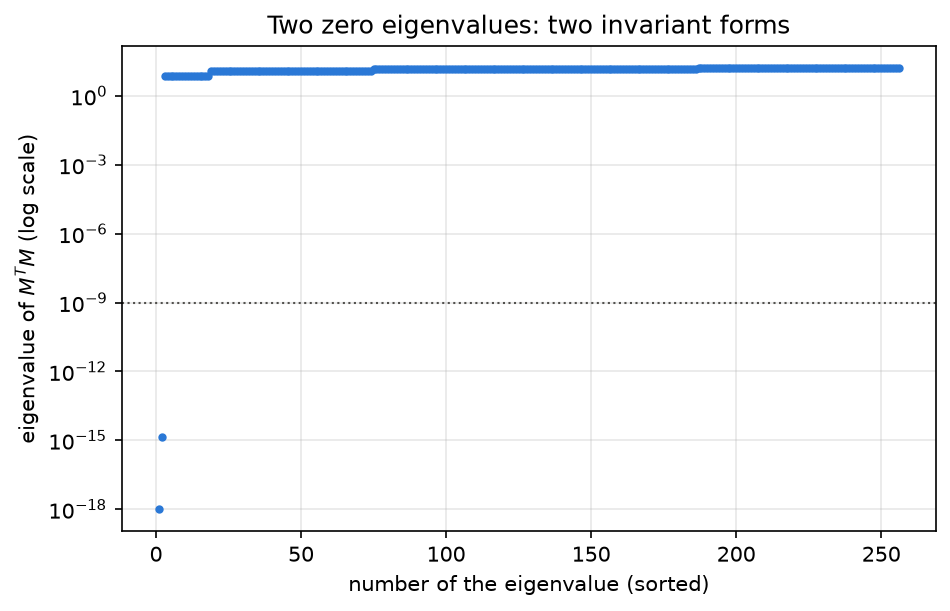

Figure 10e.2 saved as Revision/textbook/figures/10e_2_singular_values.png


In [4]:
titles = {"C P_minus": "$CP_-$ (components 1 to 8)",
          "C P_plus": "$CP_+$ (components 9 to 16)"}
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0))
for ax, (label, G) in zip(axes, forms.items()):
    image = ax.imshow(G, cmap=DIVERGING, vmin=-1, vmax=1)
    ticks = list(range(0, 16, 3))
    ax.set_xticks(ticks, [str(t + 1) for t in ticks])
    ax.set_yticks(ticks, [str(t + 1) for t in ticks])
    ax.grid(False)
    ax.set_title(titles[label])
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry")
save_figure(fig, "invariant_forms",
            "The two independent Spin(4,4)-invariant bilinear forms of the 16 "
            "components as heat maps: $CP_-$ (left) and $CP_+$ (right), where $C$ "
            "is the author's sigma16 and $P_\\mp$ project onto the chiral halves "
            "(rows and columns 1 to 8, and 9 to 16). Horizontal axis: column "
            "number, vertical axis: row number; red $+1$, blue $-1$, light grey 0. "
            "Every invariant form is a combination of these two; $C = CP_- + CP_+$ "
            "gives the scalar $\\bar\\Psi\\Psi$.")

fig, ax = plt.subplots()
ax.semilogy(range(1, 257), np.maximum(values, 1e-18), "o", color=BLUE, markersize=3)
ax.axhline(1e-9, color=GREY, linestyle=":", linewidth=1)
ax.set_xlabel("number of the eigenvalue (sorted)")
ax.set_ylabel("eigenvalue of $M^TM$ (log scale)")
ax.set_title("Two zero eigenvalues: two invariant forms")
save_figure(fig, "singular_values",
            "The 256 eigenvalues of $M^TM$ (vertical axis, logarithmic scale, pure "
            "numbers; values below $10^{-18}$ drawn at $10^{-18}$), sorted from the "
            "smallest (horizontal axis: their number). $M$ collects the equations "
            "$(S^{ab})^TG + GS^{ab} = 0$ for the 28 generators. Exactly two "
            "eigenvalues lie at the rounding level, far below the dotted line at "
            "$10^{-9}$, and all others are at least about 7: the invariant forms "
            "make a two-dimensional family.")

## 7. Every invariant charge density is indefinite

The next cell takes 40 random invariant forms $G = r_-CP_- + r_+CP_+$ (real $r_\mp$,
because $CP_\mp$ is real and symmetric, so $G$ is Hermitian exactly for real
coefficients) and random complex numbers $c$, builds the Hermitian part $X =
\frac12(cG\gamma^{(x_4)} + (cG\gamma^{(x_4)})^\dagger)$, and checks $\Gamma X\Gamma =
-X$ and that $X$ has eight positive and eight negative eigenvalues (every sample has
$X \neq 0$). It also checks that the canonical choice $c = -i$, $r_\mp = 1$ gives
$X = B$ with eigenvalues $\pm1$, eight each.

PASS 40 random invariant densities: Gamma X Gamma = -X, 8 positive, 8 negative
PASS the canonical density is B, with eigenvalues -1 and +1, eight each
     reproduces Revision/algebra/reports/wolfram-algebra.json, check B_signature_8_8


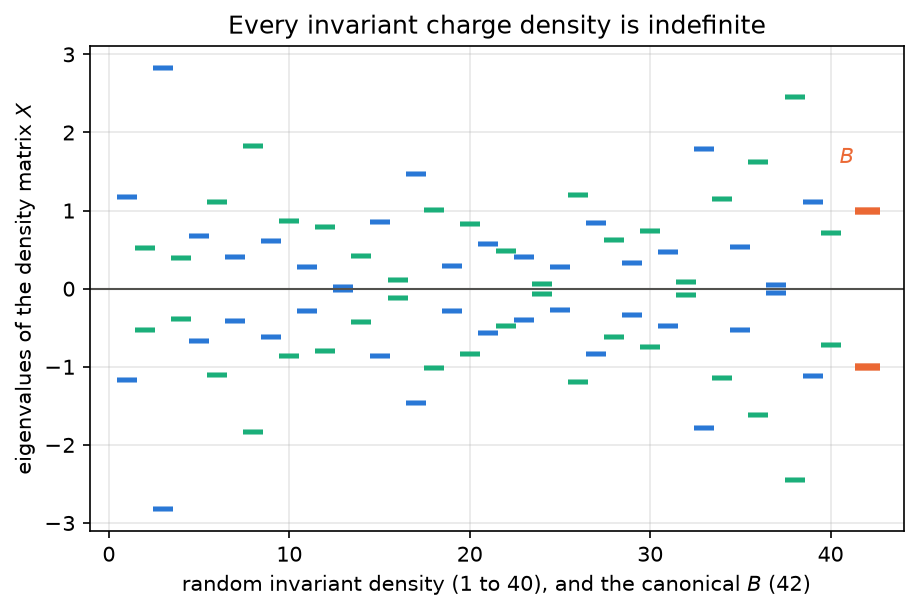

Figure 10e.3 saved as Revision/textbook/figures/10e_3_density_eigenvalues.png


In [5]:
rng = np.random.default_rng(12345)
spectra, all_ok = [], True
for _ in range(40):
    r_minus, r_plus = rng.normal(size=2)
    c = complex(rng.normal(), rng.normal())
    G = r_minus * C @ P_minus + r_plus * C @ P_plus
    Y = c * G @ gamma[4]
    X = (Y + Y.conj().T) / 2  # the Hermitian part
    eigenvalues = np.linalg.eigvalsh(X)
    spectra.append(eigenvalues)
    positive = int(np.sum(eigenvalues > 1e-12))  # how many eigenvalues are > 0
    negative = int(np.sum(eigenvalues < -1e-12))  # how many are < 0
    all_ok = (all_ok and np.allclose(Gamma @ X @ Gamma, -X)
              and positive == 8 and negative == 8)
G_canonical = C @ P_minus + C @ P_plus  # = C
Y = -1j * G_canonical @ gamma[4]
X_canonical = (Y + Y.conj().T) / 2
canonical_ok = np.allclose(X_canonical, B)
canonical_values = np.linalg.eigvalsh(X_canonical)
check(all_ok,
      "40 random invariant densities: Gamma X Gamma = -X, 8 positive, 8 negative")
check_record(canonical_ok and np.allclose(canonical_values, [-1] * 8 + [1] * 8),
             "the canonical density is B, with eigenvalues -1 and +1, eight each",
             record="Revision/algebra/reports/wolfram-algebra.json, check "
                    "B_signature_8_8")

fig, ax = plt.subplots()
for index, eigenvalues in enumerate(spectra, 1):
    ax.plot([index] * 16, eigenvalues, "_", color=BLUE if index % 2 else GREEN,
            markersize=10, markeredgewidth=2)
ax.plot([42] * 16, canonical_values, "_", color=ORANGE, markersize=12,
        markeredgewidth=3)
ax.annotate("$B$", (42, 1.0), xytext=(40.5, 1.6), color=ORANGE)
ax.axhline(0.0, color=GREY, linewidth=1)
ax.set_xlabel("random invariant density (1 to 40), and the canonical $B$ (42)")
ax.set_ylabel("eigenvalues of the density matrix $X$")
ax.set_title("Every invariant charge density is indefinite")
save_figure(fig, "density_eigenvalues",
            "The 16 eigenvalues (vertical axis, pure numbers) of 40 random "
            "Spin(4,4)-invariant charge densities $X$, the Hermitian part of "
            "$cG\\gamma^{(x_4)}$ with $G = r_-CP_- + r_+CP_+$ (horizontal axis: the "
            "sample number; blue and green alternate), and of the canonical "
            "density $B$ (orange, at 42). Every density has eight positive and "
            "eight negative eigenvalues, mirror images in the grey line: no "
            "invariant choice makes the charge positive, because the time gamma "
            "$\\gamma^{(x_4)}$ is odd and every invariant form even under the "
            "chirality $\\Gamma$.")

## 8. Which generators keep the canonical anticommutator?

The next cell sorts the 28 generators. For each it records whether it is
anti-Hermitian ($S^\dagger = -S$; its exponential is then unitary), whether it
commutes with $B$, and whether it satisfies the Krein condition $S^\dagger B + BS
= 0$ (its exponential then keeps $B$ and the canonical anticommutator). The Revision
record states that the Krein condition holds exactly for the 21 generators with
$a, b \neq x_4$ and that for the 7 generators $S^{(x_4b)}$ (with $x_4$ written first)
the left-hand side equals $iC\gamma^{(x_b)}$.

In [6]:
kinds = {}
for (a, b), s in S.items():
    anti_hermitian = np.array_equal(s.conj().T, -s)
    commutes = np.allclose(B @ s, s @ B)
    krein = np.allclose(s.conj().T @ B + B @ s, 0)
    kinds[(a, b)] = (anti_hermitian, commutes, krein)
counts = {"anti-Hermitian (unitary)": sum(k[0] for k in kinds.values()),
          "commute with B": sum(k[1] for k in kinds.values()),
          "Krein-unitary": sum(k[2] for k in kinds.values()),
          "both unitary and Krein-unitary": sum(k[0] and k[2] for k in kinds.values())}
for label, number in counts.items():
    report(label, number)
krein_pairs = sorted(pair for pair, k in kinds.items() if k[2])
off_x4 = sorted(pair for pair in pairs if 4 not in pair)
x4_ok = True
for (a, b), s in S.items():
    if 4 in (a, b):
        other = b if a == 4 else a
        s_x4_first = s if a == 4 else -s  # S^(x4 b) = -S^(b x4)
        left = s_x4_first.conj().T @ B + B @ s_x4_first
        x4_ok = x4_ok and np.allclose(left, 1j * C @ gamma[other])
check_record(krein_pairs == off_x4 and len(krein_pairs) == 21 and x4_ok,
             "Krein-unitary: exactly the 21 generators without x4 (Spin(4,3))",
             record="Revision/algebra/reports/wolfram-algebra.json, check "
                    "S_preserves_B_only_off_x4")
check(counts["anti-Hermitian (unitary)"] == 12 and counts["commute with B"] == 13
      and counts["both unitary and Krein-unitary"] == 9,
      "counts: 12 anti-Hermitian, 13 commute with B, 9 both unitary and Krein")

RESULT anti-Hermitian (unitary) = 12
RESULT commute with B = 13
RESULT Krein-unitary = 21
RESULT both unitary and Krein-unitary = 9
PASS Krein-unitary: exactly the 21 generators without x4 (Spin(4,3))
     reproduces Revision/algebra/reports/wolfram-algebra.json, check
    S_preserves_B_only_off_x4
PASS counts: 12 anti-Hermitian, 13 commute with B, 9 both unitary and Krein


The next cell draws the 28 generators as the squares above the diagonal of an
$8 \times 8$ grid (row $a$, column $b$, $a < b$), coloured by their kind: blue for
the 9 that are unitary AND Krein-unitary (rotations among $x_1, x_2, x_3, x_8$ and
among $x_5, x_6, x_7$), green for the 12 that are Krein-unitary but not unitary
(boosts mixing $x_1, x_2, x_3, x_8$ with $x_5, x_6, x_7$), orange for the 7 that
involve $x_4$ and break the canonical anticommutator.

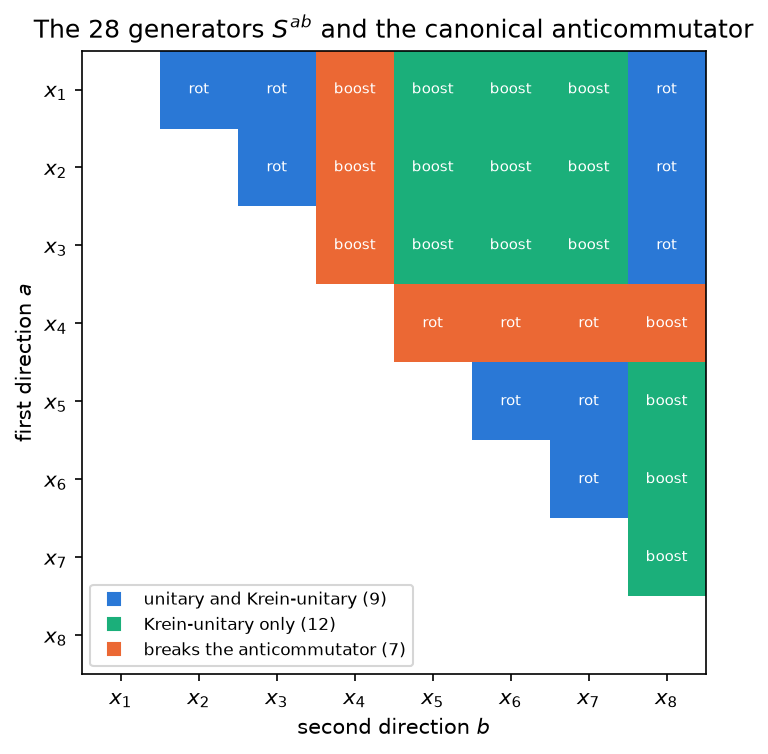

Figure 10e.4 saved as Revision/textbook/figures/10e_4_generator_types.png


In [7]:
grid = np.full((8, 8), np.nan)  # NaN: no generator (diagonal and below)
for (a, b), (anti_hermitian, _, krein) in kinds.items():
    grid[a - 1, b - 1] = 0 if (anti_hermitian and krein) else (1 if krein else 2)
colours = ListedColormap([BLUE, GREEN, ORANGE])
fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.imshow(grid, cmap=colours, vmin=-0.5, vmax=2.5)
names = [f"$x_{a}$" for a in range(1, 9)]
ax.set_xticks(range(8), names)
ax.set_yticks(range(8), names)
ax.grid(False)
for (a, b), (anti_hermitian, _, krein) in kinds.items():
    mark = "rot" if anti_hermitian else "boost"  # a rotation or a boost
    ax.text(b - 1, a - 1, mark, ha="center", va="center", color="white", fontsize=7)
ax.plot([], [], "s", color=BLUE, label="unitary and Krein-unitary (9)")
ax.plot([], [], "s", color=GREEN, label="Krein-unitary only (12)")
ax.plot([], [], "s", color=ORANGE, label="breaks the anticommutator (7)")
ax.legend(loc="lower left", fontsize=8)
ax.set_xlabel("second direction $b$")
ax.set_ylabel("first direction $a$")
ax.set_title("The 28 generators $S^{ab}$ and the canonical anticommutator")
save_figure(fig, "generator_types",
            "The 28 generators $S^{ab}$ of Spin(4,4), one square for each pair of "
            "directions $a < b$ (vertical axis: $a$, horizontal axis: $b$); rot "
            "marks a rotation (anti-Hermitian generator), boost a boost (Hermitian "
            "generator). Blue: unitary and Krein-unitary (9); green: "
            "Krein-unitary but not unitary (12); orange: the 7 generators that "
            "involve the time $x_4$ and do not keep $B$. The 21 blue and green "
            "squares, every pair without $x_4$, generate Spin(4,3), the "
            "transformations that keep the canonical anticommutator.")

## 9. Finite rotations and boosts

Since $(\gamma^{(x_a)}\gamma^{(x_b)})^2 = -\eta_{aa}\eta_{bb}I$ for $a \neq b$, the
generator obeys $(S^{ab})^2 = -\frac14\eta_{aa}\eta_{bb}I$, and the exponential series
collapses: for $\eta_{aa}\eta_{bb} = +1$ (a rotation) $\exp(\theta S) =
\cos\frac\theta2\,I + 2\sin\frac\theta2\,S$, and for $\eta_{aa}\eta_{bb} = -1$ (a
boost) $\exp(\theta S) = \cosh\frac\theta2\,I + 2\sinh\frac\theta2\,S$. The next
cell checks the formula against a numerical matrix exponential (the sum of the
series up to the 30th power) and then follows a column $u$ with $u^\dagger u = 1$ and
$u^\dagger Bu = 1$ under three transformations: the rotation $S^{(x_1x_2)}$, the
boost $S^{(x_1x_5)}$ (Krein-unitary) and the boost $S^{(x_1x_4)}$ (not
Krein-unitary). It plots the squared length $(Ru)^\dagger(Ru)$ and the Krein norm
$(Ru)^\dagger B(Ru)$ against $\theta$.

In [8]:
def spin_transformation(a, b, theta):
    """exp(theta S^ab) from the closed formula."""
    s = S[(a, b)]
    if eta[a] * eta[b] == 1:  # a rotation
        return np.cos(theta / 2) * I16 + 2 * np.sin(theta / 2) * s
    return np.cosh(theta / 2) * I16 + 2 * np.sinh(theta / 2) * s  # a boost


def series_exponential(matrix, terms=30):
    """exp(matrix) as the sum of matrix^n / n! for n = 0, ..., terms."""
    result, power = np.eye(16), np.eye(16)
    for n in range(1, terms + 1):
        power = power @ matrix / n
        result = result + power
    return result


worst = max(np.max(np.abs(spin_transformation(a, b, 0.7)
                          - series_exponential(0.7 * S[(a, b)]))) for a, b in pairs)
report("largest difference between the formula and the series", f"{worst:.1e}")
check(worst < 1e-12, "the closed formula for exp(theta S^ab) is right for all 28")

u = ((I16 + B) / 2)[:, 0]  # a column with B u = u
u = u / np.linalg.norm(u)
thetas = np.linspace(-3.0, 3.0, 241)
curves = {}
for pair in ((1, 2), (1, 5), (1, 4)):
    lengths, kreins = [], []
    for theta in thetas:
        v = spin_transformation(*pair, theta) @ u
        lengths.append((v.conj() @ v).real)
        kreins.append((v.conj() @ B @ v).real)
    curves[pair] = (np.array(lengths), np.array(kreins))
kept = {pair: np.max(np.abs(curves[pair][1] - 1)) < 1e-12 for pair in curves}
say(f"Krein norm kept: rotation x1x2 {kept[(1, 2)]}, boost x1x5 {kept[(1, 5)]}, "
    f"boost x1x4 {kept[(1, 4)]}")
check(kept[(1, 2)] and kept[(1, 5)] and not kept[(1, 4)]
      and np.max(np.abs(curves[(1, 2)][0] - 1)) < 1e-12,
      "finite: the rotation keeps both norms, the x1x5 boost only the Krein norm")

RESULT largest difference between the formula and the series = 6.7e-16
PASS the closed formula for exp(theta S^ab) is right for all 28
Krein norm kept: rotation x1x2 True, boost x1x5 True, boost x1x4 False
PASS finite: the rotation keeps both norms, the x1x5 boost only the Krein norm


The next cell draws the two norms for the three transformations.

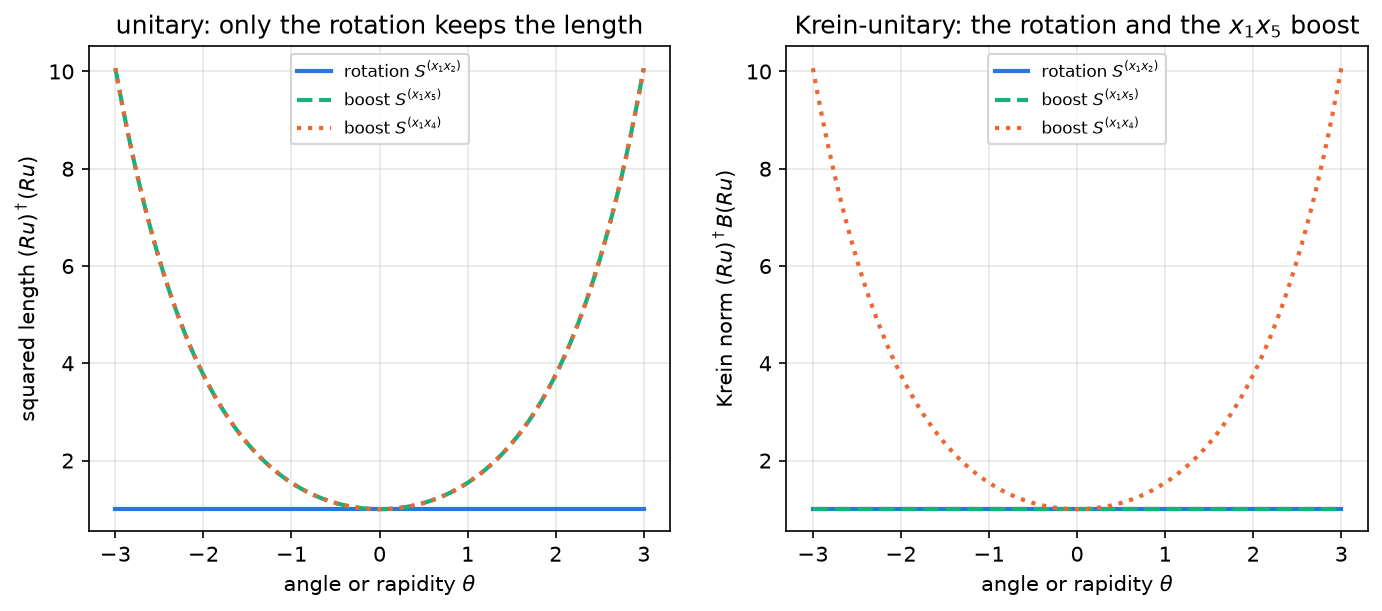

Figure 10e.5 saved as Revision/textbook/figures/10e_5_finite_transformations.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True)
styles = {(1, 2): (BLUE, "-", "rotation $S^{(x_1x_2)}$"),
          (1, 5): (GREEN, "--", "boost $S^{(x_1x_5)}$"),
          (1, 4): (ORANGE, ":", "boost $S^{(x_1x_4)}$")}
for pair, (colour, style, label) in styles.items():
    axes[0].plot(thetas, curves[pair][0], style, color=colour, linewidth=2,
                 label=label)
    axes[1].plot(thetas, curves[pair][1], style, color=colour, linewidth=2,
                 label=label)
axes[0].set_ylabel("squared length $(Ru)^\\dagger(Ru)$")
axes[1].set_ylabel("Krein norm $(Ru)^\\dagger B (Ru)$")
for ax in axes:
    ax.set_xlabel("angle or rapidity $\\theta$")
    ax.legend(fontsize=8)
axes[0].set_title("unitary: only the rotation keeps the length")
axes[1].set_title("Krein-unitary: the rotation and the $x_1x_5$ boost")
save_figure(fig, "finite_transformations",
            "A column $u$ with $u^\\dagger u = 1$ and $u^\\dagger Bu = 1$ transformed "
            "by $R = \\exp(\\theta S^{ab})$ for the angle or rapidity $\\theta$ from "
            "$-3$ to $3$ (horizontal axes): the rotation $S^{(x_1x_2)}$ (blue), the "
            "boost $S^{(x_1x_5)}$ between a space direction and an extra time (green "
            "dashed) and the boost $S^{(x_1x_4)}$ that involves the time $x_4$ "
            "(orange dotted). Left: the squared length, kept only by the rotation. "
            "Right: the Krein norm, kept by the rotation and by the $x_1x_5$ boost, "
            "but not by the boost that involves $x_4$. Vertical axes: pure numbers.")

## 10. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [10]:
for name in ("10e_1_invariant_forms.png", "10e_2_singular_values.png",
             "10e_3_density_eigenvalues.png", "10e_4_generator_types.png",
             "10e_5_finite_transformations.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10e_1_invariant_forms.png exists
PASS the figure file 10e_2_singular_values.png exists
PASS the figure file 10e_3_density_eigenvalues.png exists
PASS the figure file 10e_4_generator_types.png exists
PASS the figure file 10e_5_finite_transformations.png exists
ALL 15 CHECKS PASSED (notebook 10e)


## 11. What this notebook showed

- COMPUTED (with a separation of many orders of magnitude between zero and nonzero
  eigenvalues) and CHECKED EXACTLY: the bilinear forms invariant under all 28
  generators of Spin(4,4) form a two-dimensional family, spanned by $CP_-$ and
  $CP_+$; $C$ itself gives the scalar $\bar\Psi\Psi$.
- PROVED (Section 4) and CHECKED for 40 random choices: every charge density built
  from an invariant form and the time gamma, the Hermitian part of
  $cG\gamma^{(x_4)}$, satisfies $\Gamma X\Gamma = -X$ and has eight positive and
  eight negative eigenvalues. The indefinite (Krein) charge of dirac16complex is not
  an accident of the choice $B$: in signature (4,4) no invariant density is
  positive.
- REPRODUCED: exactly the 21 generators that do not involve $x_4$ are
  Krein-unitary (they generate Spin(4,3), the transformations that keep the
  canonical anticommutator), and for the 7 generators $S^{(x_4b)}$ the defect is
  $iC\gamma^{(x_b)}$; of the 21, the 9 rotations among $x_1, x_2, x_3, x_8$ and among
  $x_5, x_6, x_7$ are also unitary. COMPUTED: the counts 12 (anti-Hermitian) and 13
  (commuting with $B$).
- The canonical structure singles out the time $x_4$, as $\Psi^\dagger\Psi$ does in
  ordinary Dirac theory; transformations that turn $x_4$ into another direction
  (here the 7 generators with $x_4$) do not keep $B$, and the slices $x_4 = $ const
  on which the theory is quantised are then changed as well.